In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

sys.path.append(os.path.abspath('../scripts'))
import ocean_analysis as oa 

c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:683: RuntimeWarning: Mean of empty slice
  mean_zonal_density = np.nanmean(np.asarray(all_zonal_density), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:684: RuntimeWarning: Mean of empty slice
  mean_merid_density = np.nanmean(np.asarray(all_merid_density), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:683: RuntimeWarning: Mean of empty slice
  mean_zonal_density = np.nanmean(np.asarray(all_zonal_density), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:684: RuntimeWarning: Mean of empty slice
  mean_merid_density = np.nanmean(np.asarray(all_merid_density), axis=0)
c:\Users\Jel

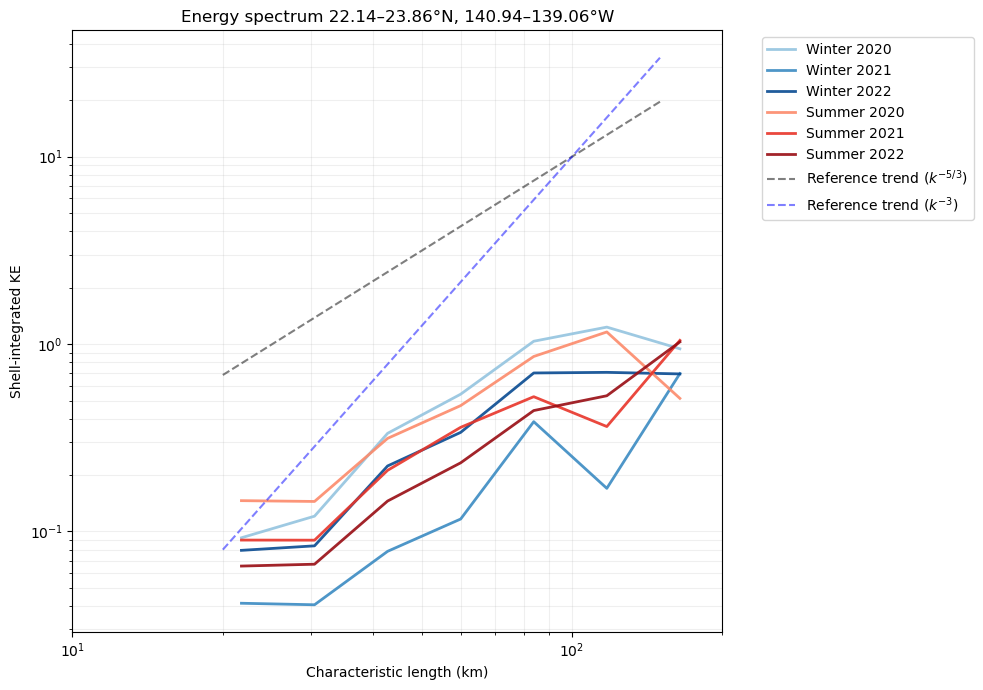

''

In [16]:
# 1. Define Subdomain
# lat_s, lat_n = 20.0, 45.0
# lon_w, lon_e = -155.0, -130.0

lat_s, lat_n = 22.14, 23.86
lon_w, lon_e = -140.94, -139.06



les_box = [lon_w, lon_e, lat_s, lat_n]

# 2. Setup Dataset Groups and Color Families
data_groups = {
    "Winter": {
        "2020": "../data/GPGP_jan2020.nc",
        "2021": "../data/GPGP_jan2021.nc",
        "2022": "../data/GPGP_jan2022.nc",
    },
    "Summer": {
        "2020": "../data/GPGP_aug2020.nc",
        "2021": "../data/GPGP_aug2021.nc",
        "2022": "../data/GPGP_aug2022.nc",
    },
}

base_colors = {
    "Winter": "Blues",
    "Summer": "Reds",
    "Spring": "Greens",
    "Autumn": "Oranges",
}

MAX_W = 200

plt.figure(figsize=(10, 7))

for season, years in data_groups.items():
    cmap = plt.get_cmap(base_colors[season])
    shades = np.linspace(0.4, 0.9, len(years))

    for idx, (year_label, path) in enumerate(years.items()):
        eds = oa.calculate_EDS(
            filepath=path,
            target_box=les_box,
            max_wavelength_km=MAX_W,
            initialized_velocity=False,
            n_bins=8,
            remove_mean=True,
            window=None,          #  None / "hann" / "tukey"
            tukey_alpha=0.1,
            direction_half_width_deg=15.0,
        )

        l_km = eds["characteristic_length"].values / 1000.0
        E = eds["shell_integrated_spectrum"].values

        valid = np.isfinite(l_km) & np.isfinite(E) & (l_km > 0) & (E > 0)

        plt.loglog(
            l_km[valid],
            E[valid],
            label=f"{season} {year_label}",
            color=cmap(shades[idx]),
            lw=2,
            alpha=0.9,
        )

# Initialized field EDS
eds_init = oa.calculate_EDS(
    filepath="../data/init_surface_uv.nc",
    target_box=None,
    max_wavelength_km=192 / 2,
    initialized_velocity=True,
    x_res=500.0,
    y_res=500.0,
    n_bins=8,
    remove_mean=True,
    window=None,              # keep same choice as above for fair comparison
    tukey_alpha=0.1,
    direction_half_width_deg=15.0,
)

l_km_init = eds_init["characteristic_length"].values / 1000.0
E_init = eds_init["shell_integrated_spectrum"].values

valid_init = np.isfinite(l_km_init) & np.isfinite(E_init) & (l_km_init > 0) & (E_init > 0)

# plt.loglog(
#     l_km_init[valid_init],
#     E_init[valid_init],
#     label="Initial Surface UV",
#     color="black",
#     lw=3,
# )

# Reference slopes
# These are only qualitative here, because this plot is shell-integrated spectrum vs length.
x_ref = np.array([20.0, 150.0])
y_ref = 10**1 * (x_ref / 100.0) ** (5 / 3)
y_ref_enstrophy = 10**1 * (x_ref / 100.0) ** 3

plt.loglog(
    x_ref,
    y_ref,
    "k--",
    alpha=0.5,
    label=r"Reference trend ($k^{-5/3}$)",
)

plt.loglog(
    x_ref,
    y_ref_enstrophy,
    "b--",
    alpha=0.5,
    label=r"Reference trend ($k^{-3}$)",
)

plt.xlabel("Characteristic length (km)")
plt.ylabel("Shell-integrated KE")
plt.title(f"Energy spectrum {lat_s}–{lat_n}°N, {abs(lon_w)}–{abs(lon_e)}°W")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, which="both", alpha=0.2)
plt.xlim(10, MAX_W)
plt.tight_layout()
plt.show()
;

c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:683: RuntimeWarning: Mean of empty slice
  mean_zonal_density = np.nanmean(np.asarray(all_zonal_density), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:684: RuntimeWarning: Mean of empty slice
  mean_merid_density = np.nanmean(np.asarray(all_merid_density), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:683: RuntimeWarning: Mean of empty slice
  mean_zonal_density = np.nanmean(np.asarray(all_zonal_density), axis=0)
c:\Users\Jelle Gortemaker\OneDrive - Delft University of Technology\Documenten\0. MSc\#.Thesis\Thesis\OGCM\scripts\ocean_analysis.py:684: RuntimeWarning: Mean of empty slice
  mean_merid_density = np.nanmean(np.asarray(all_merid_density), axis=0)
c:\Users\Jel

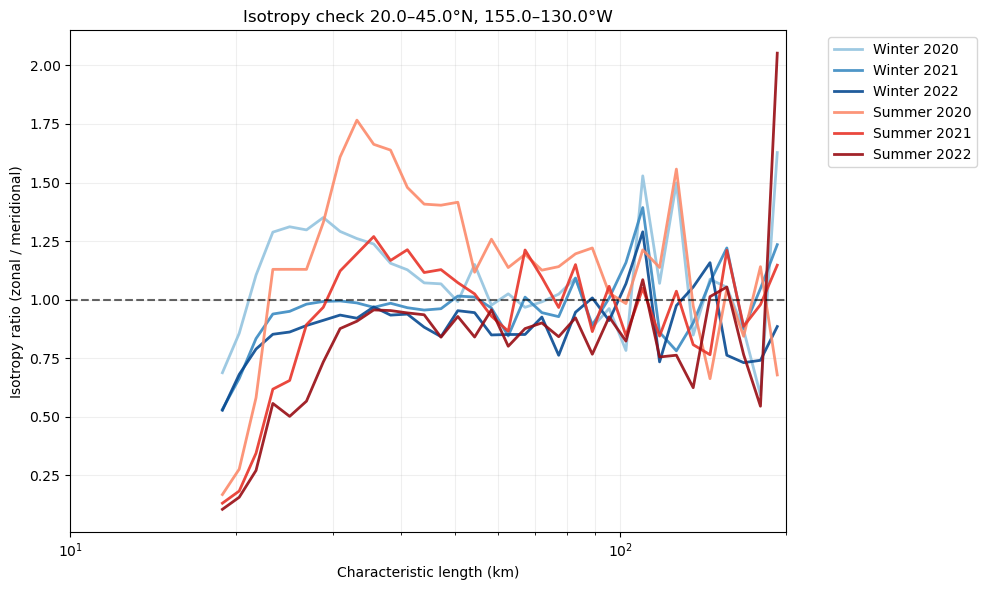

''

In [12]:
plt.figure(figsize=(10, 6))

for season, years in data_groups.items():
    cmap = plt.get_cmap(base_colors[season])
    shades = np.linspace(0.4, 0.9, len(years))

    for idx, (year_label, path) in enumerate(years.items()):
        eds = oa.calculate_EDS(
            filepath=path,
            target_box=les_box,
            max_wavelength_km=MAX_W,
            initialized_velocity=False,
            window="tukey",
            tukey_alpha=0.1,
            direction_half_width_deg=30.0,
        )

        l_km = eds["characteristic_length"].values / 1000.0
        R = eds["isotropy_ratio"].values

        valid = np.isfinite(l_km) & np.isfinite(R) & (l_km > 0) & (R > 0)

        plt.semilogx(
            l_km[valid],
            R[valid],
            label=f"{season} {year_label}",
            color=cmap(shades[idx]),
            lw=2,
            alpha=0.9,
        )

plt.axhline(1.0, color="k", linestyle="--", alpha=0.6)
plt.xlabel("Characteristic length (km)")
plt.ylabel("Isotropy ratio (zonal / meridional)")
plt.title(f"Isotropy check {lat_s}–{lat_n}°N, {abs(lon_w)}–{abs(lon_e)}°W")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, which="both", alpha=0.2)
plt.xlim(10, MAX_W)
plt.tight_layout()
plt.show()
;